In [27]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import pandas as pd
df = pd.read_csv("OneDrive/Desktop/Weekly class(ai with ml)/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [34]:
print("shape of dataset:",df.shape)
print()
print("column name:")
print(df.info())
print()
print("statisstical summary:")
print(df.describe())
print()
print("Missing values:")
print(df.isnull().sum())

shape of dataset: (7043, 7073)

column name:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Columns: 7073 entries, SeniorCitizen to PaymentMethod_Mailed check
dtypes: bool(7068), float64(2), int64(3)
memory usage: 47.7 MB
None

statisstical summary:
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges        Churn
count    7043.000000  7043.000000     7043.000000   7043.000000  7043.000000
mean        0.162147    32.371149       64.761692   2281.916928     0.265370
std         0.368612    24.559481       30.090047   2265.270398     0.441561
min         0.000000     0.000000       18.250000     18.800000     0.000000
25%         0.000000     9.000000       35.500000    402.225000     0.000000
50%         0.000000    29.000000       70.350000   1397.475000     0.000000
75%         0.000000    55.000000       89.850000   3786.600000     1.000000
max         1.000000    72.000000      118.750000   8684.800000     1.000000

Missing values:
SeniorCitizen

In [35]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Remove rows with missing values
df.dropna(inplace=True)

# Convert Churn to numeric
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(df.head())
print()
print(df.info())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  \
0              0       1           29.85         29.85    NaN   
1              0      34           56.95       1889.50    NaN   
2              0       2           53.85        108.15    NaN   
3              0      45           42.30       1840.75    NaN   
4              0       2           70.70        151.65    NaN   

   customerID_0003-MKNFE  customerID_0004-TLHLJ  customerID_0011-IGKFF  \
0                  False                  False                  False   
1                  False                  False                  False   
2                  False                  False                  False   
3                  False                  False                  False   
4                  False                  False                  False   

   customerID_0013-EXCHZ  customerID_0013-MHZWF  ...  \
0                  False                  False  ...   
1                  False                  False  ...

In [13]:
from sklearn.preprocessing import LabelEncoder

# Encode target column
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])  # Yes=1, No=0

# One-hot encode other categorical columns
df = pd.get_dummies(df, drop_first=True)

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

C:\Users\kumaravel\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                  tenure  MonthlyCharges  TotalCharges     Churn
tenure          1.000000        0.247900      0.825464 -0.352229
MonthlyCharges  0.247900        1.000000      0.650864  0.193356
TotalCharges    0.825464        0.650864      1.000000 -0.199037
Churn          -0.352229        0.193356     -0.199037  1.000000


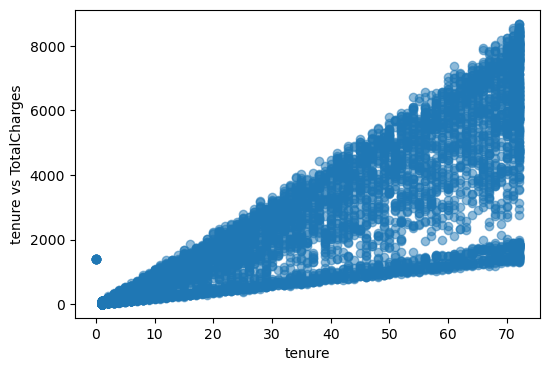

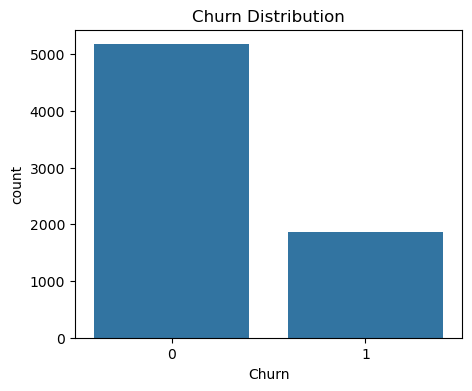

In [19]:
#Step 5 eda
numeric_df=df[["tenure","MonthlyCharges","TotalCharges","Churn"]]
print(numeric_df.corr())

#Scatter plot tenure vs totalcharges
plt.figure(figsize=(6,4))
plt.scatter(df["tenure"],df["TotalCharges"],alpha=0.5)
plt.xlabel("tenure")
plt.ylabel("tenure vs TotalCharges")
plt.show()
#Churn distribution
plt.figure(figsize=(5,4))
sns.countplot(x=df["Churn"])
plt.title("Churn Distribution")
plt.show()

In [20]:
#step 6:select feature and target
x=df[["tenure","MonthlyCharges"]]
y=df["TotalCharges"]
print(x.head())
print()
print(y.head())

   tenure  MonthlyCharges
0       1           29.85
1      34           56.95
2       2           53.85
3      45           42.30
4       2           70.70

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64


In [21]:
#step 7:split the dataset 
X_train,X_test,Y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Training data shape:",X_train.shape)
print("Tresting data shape:",X_test.shape)

Training data shape: (5634, 2)
Tresting data shape: (1409, 2)


In [36]:
# Step 9: Make predictions
y_pred = linear_model.predict(X_test)

print("Predicted values:")
print(y_pred[:5])
from sklearn.linear_model import LinearRegression

# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit(X_train, y_train)

# Make predictions
y_pred = linear_model.predict(X_test)

print("Predicted values:")
print(y_pred[:5])

Predicted values:
[-1190.9555855   1443.40828852  1953.3221457    645.00067625
  4046.38838017]
Predicted values:
[ 0.3301451   0.02843328 -0.08063191  0.55345587 -0.05934877]
